# EMO addressable population — segmented EDA

**Audience:** Growth / marketing outreach (EMO second-opinion targeting)

## Questions this notebook answers

1. **Segmented EDA:** Clients **with claims** vs **without claims** (CY2025 parent EMO accounts).
2. **Outreach member list (Allison Kim):** Members with any of `COMPLEX_PATIENTS`, `MSK_NEURO`, `HIGH_COST` while eligible in the **same calendar month** (`member_risk_assessments.history:v1`).
3. **With-claims strategy:** Among claims clients, how many **outreach-list** members also have **paid claims history** (claims are *not* in Allison’s selection logic; we test adding that filter).
4. **Without-claims strategy:** Benchmark addressable % from **with-claims** clients; extrapolate to no-claims clients (directional).
5. **Logic verification:** Audit whether claims are used in outreach identification (Allison list + *EMO Segments for outreach* doc); see Step 8 and `docs/emo-outreach-logic-verification.md`.

**Prerequisite:** In a terminal:

```bash
aws-environment production enduser_yellow_production
```

Run with cwd = `modules/standard_reports/project_scrappy/`.

## Step 1: Connect to Lasik

In [11]:
import os
from datetime import date
from pathlib import Path

import laaso
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.environ.setdefault('AWS_ENVIRONMENT', 'production')

client = laaso.Client(catalog_type=laaso.CatalogType.YELLOW, env='production')
dialect = laaso.SqlDialect.PRESTO

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'queries' / 'emo_nav_br' / 'emo_addressable_eda.sql').exists():
    NOTEBOOK_DIR = Path.cwd() / 'modules' / 'standard_reports' / 'project_scrappy'

QUERY_PATH = NOTEBOOK_DIR / 'queries' / 'emo_nav_br' / 'emo_addressable_eda.sql'
EXPORT_DIR = NOTEBOOK_DIR / 'query_data' / 'emo_addressable'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print('Notebook dir:', NOTEBOOK_DIR.resolve())

Notebook dir: /Users/john.kimutai/customerinsights-analytics/modules/standard_reports/project_scrappy


## Step 2: Parameters

In [12]:
REPORT_START = '2025-01-01'
REPORT_END = '2026-01-01'  # end-exclusive (CY2025)
CLAIMS_TRUST_LOOKBACK = '2024-01-01'
RUN_DATE = date.today().strftime('%Y%m%d')

# Allison Kim — EMO marketing outreach selection logic (members matching ANY code)
OUTREACH_RISK_ASSESSMENTS = [
    'COMPLEX_PATIENTS',
    'MSK_NEURO',
    'HIGH_COST',
]

PARAMS = {
    'report_start_date': REPORT_START,
    'report_end_date': REPORT_END,
    'claims_trust_lookback_date': CLAIMS_TRUST_LOOKBACK,
}

## Step 3: Load warehouse data

In [13]:
def load_sql(final_cte: str) -> str:
    sql = QUERY_PATH.read_text()
    for key, val in PARAMS.items():
        sql = sql.replace('{' + key + '}', val)
    return sql.format(final_cte=final_cte)


def run_query(final_cte: str) -> pd.DataFrame:
    q = load_sql(final_cte)
    print(f'Running final_cte={final_cte}...')
    return client.pandas.query(q, dialect)


df_clients = run_query('client_claims_profile')
df_client_eda = run_query('client_eda')
df_outreach_list = run_query('outreach_member_list')
assert set(df_outreach_list['outreach_riskassessment'].unique()).issubset(
    set(OUTREACH_RISK_ASSESSMENTS)
)
print('Clients:', len(df_clients))
print('Outreach member-rows:', len(df_outreach_list))
print('Distinct outreach members:', df_outreach_list['entity_id'].nunique())

Running final_cte=client_claims_profile...
Running final_cte=client_eda...
Running final_cte=outreach_member_list...
Clients: 102
Outreach member-rows: 675691
Distinct outreach members: 489406


## Step 4: Segmented EDA — clients with vs without claims

In [14]:
workstream_summary = (
    df_client_eda.groupby('client_workstream', dropna=False)
    .agg(
        n_clients=('client_account_id', 'count'),
        total_outreach_members=('n_outreach_members', 'sum'),
        total_addressable_risk_claims=('n_addressable_risk_and_claims_history', 'sum'),
        median_pct_on_outreach_list=('pct_eligible_on_outreach_list', 'median'),
        median_pct_addressable=('pct_addressable_risk_and_claims', 'median'),
    )
    .reset_index()
    .sort_values('n_clients', ascending=False)
)
display(workstream_summary)

claims_present = df_client_eda['is_claims_present'].value_counts().rename_axis('is_claims_present').reset_index(name='n_clients')
display(claims_present)

,client_workstream,n_clients,total_outreach_members,total_addressable_risk_claims,median_pct_on_outreach_list,median_pct_addressable
0,WITHOUT_CLAIMS,61,931,0,0.0007,0.0000
1,WITH_CLAIMS,41,489813,482249,0.1977,0.1945


,is_claims_present,n_clients
0,False,61
1,True,41


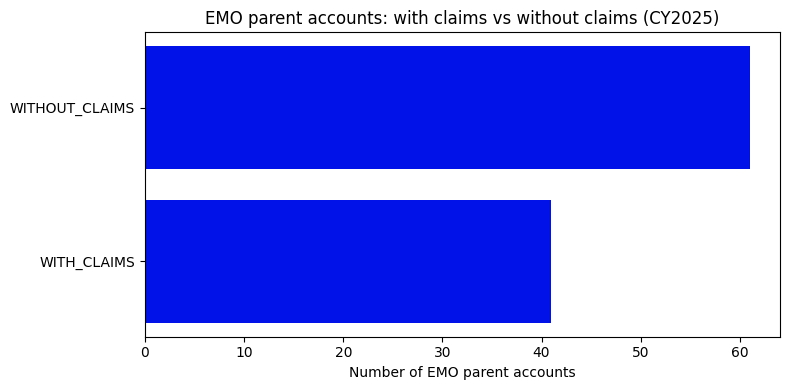

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ws = workstream_summary.sort_values('n_clients')
ax.barh(ws['client_workstream'], ws['n_clients'], color='#0012E7')
ax.set_xlabel('Number of EMO parent accounts')
ax.set_title('EMO parent accounts: with claims vs without claims (CY2025)')
plt.tight_layout()
plt.show()

## Step 5: With-claims cohort — risk vs risk + paid claims history

Allison’s outreach list = **risk codes only** (above). **Addressable (strict)** = outreach-list members with **paid claims** in CY2025 — the proposed add-on for with-claims clients.

In [16]:
with_claims = df_client_eda[df_client_eda['is_claims_present'] == True].copy()  # noqa: E712

with_claims['pct_uplift_from_claims_filter'] = (
    with_claims['pct_addressable_risk_and_claims']
    / with_claims['pct_eligible_on_outreach_list'].replace(0, np.nan)
)

with_claims_summary = pd.DataFrame({
    'metric': [
        'clients',
        'outreach_list_members',
        'addressable_risk_and_claims',
        'median_pct_eligible_on_outreach_list',
        'median_pct_addressable_risk_and_claims',
    ],
    'value': [
        len(with_claims),
        with_claims['n_outreach_members'].sum(),
        with_claims['n_addressable_risk_and_claims_history'].sum(),
        with_claims['pct_eligible_on_outreach_list'].median(),
        with_claims['pct_addressable_risk_and_claims'].median(),
    ],
})
display(with_claims_summary)

top_delta = with_claims.assign(
    member_delta=with_claims['n_outreach_members']
    - with_claims['n_addressable_risk_and_claims_history']
).sort_values('member_delta', ascending=False).head(15)[
    [
        'client_account_name',
        'client_workstream',
        'n_outreach_members',
        'n_addressable_risk_and_claims_history',
        'member_delta',
        'pct_eligible_on_outreach_list',
        'pct_addressable_risk_and_claims',
    ]
]
display(top_delta)

,metric,value
0,clients,41.0000
1,outreach_list_members,489813.0000
2,addressable_risk_and_claims,482249.0000
3,median_pct_eligible_on_outreach_list,0.1977
4,median_pct_addressable_risk_and_claims,0.1945


,client_account_name,client_workstream,n_outreach_members,n_addressable_risk_and_claims_history,member_delta,pct_eligible_on_outreach_list,pct_addressable_risk_and_claims
22,"AT&T Services, Inc.",WITH_CLAIMS,74490,72900,1590,0.2034,0.1991
31,Wells Fargo,WITH_CLAIMS,93949,92591,1358,0.2401,0.2366
80,Schwan's,WITH_CLAIMS,808,7,801,0.0691,0.0006
24,Charter Communications,WITH_CLAIMS,54840,54261,579,0.2728,0.2699
90,Southwest Airlines,WITH_CLAIMS,39218,38672,546,0.2270,0.2239
93,Google,WITH_CLAIMS,76499,75990,509,0.2847,0.2828
47,Target Corporation,WITH_CLAIMS,40891,40464,427,0.1772,0.1754
73,Liberty Mutual,WITH_CLAIMS,13564,13312,252,0.1533,0.1505
28,TrustmarkSB (fka Star Marketing and Administra...,WITH_CLAIMS,5489,5264,225,0.0995,0.0954
51,Phillips 66,WITH_CLAIMS,9477,9333,144,0.2370,0.2334


## Step 6: Benchmark & extrapolation (without-claims clients)

Benchmark = distribution of `pct_addressable_risk_and_claims` among **WITH_CLAIMS** clients. Apply median (and p25–p75 band) to **WITHOUT_CLAIMS** clients.

In [17]:
benchmark_clients = df_client_eda[
    df_client_eda['client_workstream'] == 'WITH_CLAIMS'
].copy()

if benchmark_clients.empty:
    raise ValueError('No WITH_CLAIMS clients — check claims presence logic.')

bench_median = benchmark_clients['pct_addressable_risk_and_claims'].median()
bench_p25 = benchmark_clients['pct_addressable_risk_and_claims'].quantile(0.25)
bench_p75 = benchmark_clients['pct_addressable_risk_and_claims'].quantile(0.75)

print(f'Benchmark clients: {len(benchmark_clients)}')
print(f'Median addressable %: {bench_median:.2%}  (p25={bench_p25:.2%}, p75={bench_p75:.2%})')

no_claims = df_client_eda[df_client_eda['client_workstream'] == 'WITHOUT_CLAIMS'].copy()

no_claims['est_addressable_median'] = (
    no_claims['n_eligible_distinct_members'] * bench_median
).round(0)
no_claims['est_addressable_p25'] = (no_claims['n_eligible_distinct_members'] * bench_p25).round(0)
no_claims['est_addressable_p75'] = (no_claims['n_eligible_distinct_members'] * bench_p75).round(0)

extrapolation_summary = pd.DataFrame({
    'metric': ['no_claims_clients', 'eligible_members_no_claims', 'est_addressable_median_total'],
    'value': [
        len(no_claims),
        no_claims['n_eligible_distinct_members'].sum(),
        no_claims['est_addressable_median'].sum(),
    ],
})
display(extrapolation_summary)
display(
    no_claims.sort_values('n_eligible_distinct_members', ascending=False)[
        [
            'client_account_name',
            'n_eligible_distinct_members',
            'n_outreach_members',
            'est_addressable_median',
            'est_addressable_p25',
            'est_addressable_p75',
        ]
    ].head(20)
)

Benchmark clients: 41
Median addressable %: 19.45%  (p25=12.01%, p75=22.26%)


,metric,value
0,no_claims_clients,61.0
1,eligible_members_no_claims,441847.0
2,est_addressable_median_total,85939.0


,client_account_name,n_eligible_distinct_members,n_outreach_members,est_addressable_median,est_addressable_p25,est_addressable_p75
15,Humana Employees,127415,94,24782.0,15303.0,28363.0
50,Genentech,62763,194,12207.0,7538.0,13971.0
42,Visa U.S.A. Inc.,35661,72,6936.0,4283.0,7938.0
61,McKinsey,35170,25,6841.0,4224.0,7829.0
83,Compass Rose,31278,5,6084.0,3756.0,6962.0
19,Alcon,24670,9,4798.0,2963.0,5492.0
29,Andersen Corporation,23516,10,4574.0,2824.0,5235.0
64,Zurich North America,20194,31,3928.0,2425.0,4495.0
76,"Activision Blizzard, Inc.",12209,6,2375.0,1466.0,2718.0
89,Jet Propulsion Lab,11595,4,2255.0,1393.0,2581.0


## Step 7: Recommended client-level export

In [18]:
df_export = df_client_eda.copy()
df_export['benchmark_median_pct'] = bench_median
df_export['benchmark_p25_pct'] = bench_p25
df_export['benchmark_p75_pct'] = bench_p75

df_export['n_addressable_recommended'] = np.where(
    df_export['is_claims_present'],
    df_export['n_addressable_risk_and_claims_history'],
    (df_export['n_eligible_distinct_members'] * bench_median).round(0),
)
df_export['pct_addressable_recommended'] = np.where(
    df_export['is_claims_present'],
    df_export['pct_addressable_risk_and_claims'],
    bench_median,
)

out_path = EXPORT_DIR / f'emo_addressable_client_eda_{REPORT_START}_{REPORT_END}_{RUN_DATE}.csv'
df_export.to_csv(out_path, index=False)
print('Wrote', out_path)

outreach_path = EXPORT_DIR / f'emo_outreach_member_list_{REPORT_START}_{REPORT_END}_{RUN_DATE}.csv'
df_outreach_list.to_csv(outreach_path, index=False)
print('Wrote', outreach_path)

df_export.sort_values('n_addressable_recommended', ascending=False).head(10)

Wrote /Users/john.kimutai/customerinsights-analytics/modules/standard_reports/project_scrappy/query_data/emo_addressable/emo_addressable_client_eda_2025-01-01_2026-01-01_20260617.csv
Wrote /Users/john.kimutai/customerinsights-analytics/modules/standard_reports/project_scrappy/query_data/emo_addressable/emo_outreach_member_list_2025-01-01_2026-01-01_20260617.csv


,client_account_id,client_account_name,aggregation_id,aggregation_name,is_claims_present,client_workstream,n_eligible_distinct_members,n_outreach_members,n_complex_patients,n_msk_neuro,n_high_cost,n_addressable_risk_and_claims_history,pct_eligible_on_outreach_list,pct_addressable_risk_and_claims,benchmark_median_pct,benchmark_p25_pct,benchmark_p75_pct,n_addressable_recommended,pct_addressable_recommended
31,SALESCLOUD_ACCOUNT_ID:001400000129ABiAAM,Wells Fargo,SALESCLOUD_ACCOUNT_ID:001400000129ABiAAM,Wells Fargo,True,WITH_CLAIMS,391297,93949,16396,70385,47282,92591,0.2401,0.2366,0.1945,0.1201,0.2226,92591.0,0.2366
93,SALESCLOUD_ACCOUNT_ID:0014000000vp8MlAAI,Google,SALESCLOUD_ACCOUNT_ID:0014000000vp8MlAAI,Google,True,WITH_CLAIMS,268678,76499,5919,55481,41241,75990,0.2847,0.2828,0.1945,0.1201,0.2226,75990.0,0.2828
22,SALESCLOUD_ACCOUNT_ID:00140000019NKBHAA4,"AT&T Services, Inc.",SALESCLOUD_ACCOUNT_ID:00140000019NKBHAA4,"AT&T Services, Inc.",True,WITH_CLAIMS,366211,74490,13481,61910,32009,72900,0.2034,0.1991,0.1945,0.1201,0.2226,72900.0,0.1991
24,SALESCLOUD_ACCOUNT_ID:0014000000y4QK1AAM,Charter Communications,SALESCLOUD_ACCOUNT_ID:0014000000y4QK1AAM,Charter Communications,True,WITH_CLAIMS,201037,54840,10364,43650,25079,54261,0.2728,0.2699,0.1945,0.1201,0.2226,54261.0,0.2699
47,SALESCLOUD_ACCOUNT_ID:0014000000vp8MmAAI,Target Corporation,SALESCLOUD_ACCOUNT_ID:0014000000vp8MmAAI,Target Corporation,True,WITH_CLAIMS,230710,40891,6907,31627,16630,40464,0.1772,0.1754,0.1945,0.1201,0.2226,40464.0,0.1754
90,SALESCLOUD_ACCOUNT_ID:0014000000y27DNAAY,Southwest Airlines,SALESCLOUD_ACCOUNT_ID:0014000000y27DNAAY,Southwest Airlines,True,WITH_CLAIMS,172751,39218,6762,30546,18152,38672,0.2270,0.2239,0.1945,0.1201,0.2226,38672.0,0.2239
15,SALESCLOUD_ACCOUNT_ID:0015d00003Qa2MKAAZ,Humana Employees,SALESCLOUD_ACCOUNT_ID:0015d00003Qa2MKAAZ,Humana Employees,False,WITHOUT_CLAIMS,127415,94,16,65,49,0,0.0007,0.0000,0.1945,0.1201,0.2226,24782.0,0.1945
73,SALESCLOUD_ACCOUNT_ID:0014000000wCknzAAC,Liberty Mutual,SALESCLOUD_ACCOUNT_ID:0014000000wCknzAAC,Liberty Mutual,True,WITH_CLAIMS,88453,13564,492,11345,4595,13312,0.1533,0.1505,0.1945,0.1201,0.2226,13312.0,0.1505
50,SALESCLOUD_ACCOUNT_ID:0014000000vp8SzAAI,Genentech,SALESCLOUD_ACCOUNT_ID:0014000000vp8SzAAI,Genentech,False,WITHOUT_CLAIMS,62763,194,8,138,109,0,0.0031,0.0000,0.1945,0.1201,0.2226,12207.0,0.1945
95,SALESCLOUD_ACCOUNT_ID:00140000012hRLJAA2,JP Morgan Chase,SALESCLOUD_ACCOUNT_ID:00140000012hRLJAA2,JP Morgan Chase,True,WITH_CLAIMS,365637,11682,1828,9373,5346,11575,0.0319,0.0317,0.1945,0.1201,0.2226,11575.0,0.0317


## Step 8: Logic verification — are claims used in outreach identification?

Audits Allison’s list against *EMO Segments for outreach* (see `docs/emo-outreach-logic-verification.md`).

**Layer A — Outreach rule:** OR of three `riskassessment` codes + eligibility. No separate claims join.

**Layer B — Flag definitions:** `HIGH_COST` and `MSK_NEURO` require claims; `COMPLEX_PATIENTS` is mostly claims-driven (≥3 of 16 factors) with some auth paths.

This step **documents** Layer A/B and **validates** Layer B in warehouse data (flag mix on with- vs without-claims clients).

In [19]:
# --- Layer A: outreach selection rule (Allison) ---
SELECTION_AUDIT = pd.DataFrame([
    {
        'layer': 'A_outreach_selection',
        'question': 'Separate claims join in outreach rule?',
        'answer': 'No',
        'detail': 'Outreach = riskassessment IN (COMPLEX_PATIENTS, MSK_NEURO, HIGH_COST) OR + eligible',
    },
    {
        'layer': 'B_HIGH_COST',
        'question': 'Claims required to assign flag?',
        'answer': 'Yes',
        'detail': 'Med+Rx spend thresholds only (EMO Segments doc)',
    },
    {
        'layer': 'B_MSK_NEURO',
        'question': 'Claims required to assign flag?',
        'answer': 'Yes',
        'detail': 'Qualifying medical claim in last 60 days (dx/procedure pathways)',
    },
    {
        'layer': 'B_COMPLEX_PATIENTS',
        'question': 'Claims required to assign flag?',
        'answer': 'Mostly',
        'detail': '>=3 of 16 contributors; mostly claims/dx/Rx/IP/ER; some auth/ADT',
    },
])
display(SELECTION_AUDIT)

flag_breakdown = (
    df_outreach_list.groupby('outreach_riskassessment')['entity_id']
    .nunique()
    .reset_index(name='n_members_portfolio')
    .sort_values('n_members_portfolio', ascending=False)
)
flag_breakdown['claims_required_per_segment_doc'] = flag_breakdown['outreach_riskassessment'].map({
    'HIGH_COST': 'Yes — claims/spend only',
    'MSK_NEURO': 'Yes — medical claims (60d)',
    'COMPLEX_PATIENTS': 'Mostly — >=3 of 16; some auth',
})
display(flag_breakdown)

# --- Layer B: empirical — outreach on clients without claims feed ---
outreach_with_flags = df_outreach_list.merge(
    df_client_eda[['client_account_id', 'client_workstream', 'is_claims_present']],
    on='client_account_id',
    how='left',
)

empirical_by_workstream = (
    outreach_with_flags.groupby('client_workstream')
    .agg(
        n_clients=('client_account_id', 'nunique'),
        n_outreach_member_rows=('entity_id', 'count'),
        n_distinct_members=('entity_id', 'nunique'),
    )
    .reset_index()
)
display(empirical_by_workstream)

no_claims_flags = (
    outreach_with_flags.loc[
        outreach_with_flags['client_workstream'] == 'WITHOUT_CLAIMS'
    ]
    .groupby('outreach_riskassessment')['entity_id']
    .nunique()
    .reset_index(name='n_members_no_claims_clients')
)
display(no_claims_flags)

with_claims_only = df_client_eda[df_client_eda['is_claims_present'] == True].copy()  # noqa: E712
with_claims_only['pct_outreach_with_paid_claims_cy2025'] = (
    with_claims_only['n_addressable_risk_and_claims_history']
    / with_claims_only['n_outreach_members'].replace(0, np.nan)
)

portfolio_pct_on_paid_claims = (
    with_claims_only['n_addressable_risk_and_claims_history'].sum()
    / with_claims_only['n_outreach_members'].sum()
)
print(
    f"Portfolio (with-claims clients): {portfolio_pct_on_paid_claims:.1%} of outreach-list "
    'members also have paid claims in CY2025 (overlap check; flags already claims-derived).'
)

LOGIC_VERIFICATION_SUMMARY = pd.DataFrame([
    {
        'finding': 'explicit_claims_in_outreach_rule',
        'value': 'No',
        'evidence': 'Allison list = three riskassessment codes only',
    },
    {
        'finding': 'claims_used_in_flag_assignment',
        'value': 'Yes (HIGH_COST, MSK_NEURO); Mostly (COMPLEX_PATIENTS)',
        'evidence': 'EMO Segments for outreach doc',
    },
    {
        'finding': 'n_outreach_members_portfolio',
        'value': df_outreach_list['entity_id'].nunique(),
        'evidence': 'emo_outreach_member_list',
    },
    {
        'finding': 'n_outreach_on_without_claims_clients',
        'value': outreach_with_flags.loc[
            outreach_with_flags['client_workstream'] == 'WITHOUT_CLAIMS', 'entity_id'
        ].nunique(),
        'evidence': 'Should be low if HIGH_COST/MSK_NEURO require claims feed',
    },
    {
        'finding': 'pct_outreach_with_paid_claims_cy2025_with_claims_clients',
        'value': round(portfolio_pct_on_paid_claims, 4),
        'evidence': 'Empirical overlap; not a definition of outreach',
    },
])
display(LOGIC_VERIFICATION_SUMMARY)

verify_path = EXPORT_DIR / (
    f'emo_outreach_logic_verification_{REPORT_START}_{REPORT_END}_{RUN_DATE}.csv'
)
LOGIC_VERIFICATION_SUMMARY.to_csv(verify_path, index=False)
print('Wrote', verify_path)
print(
    '\nAudit conclusion: Claims are NOT a separate outreach filter (Layer A), but ARE '
    'used to identify most outreach members via risk-assessment definitions (Layer B). '
    'See docs/emo-outreach-logic-verification.md for full write-up.'
)

,layer,question,answer,detail
0,A_outreach_selection,Separate claims join in outreach rule?,No,Outreach = riskassessment IN (COMPLEX_PATIENTS...
1,B_HIGH_COST,Claims required to assign flag?,Yes,Med+Rx spend thresholds only (EMO Segments doc)
2,B_MSK_NEURO,Claims required to assign flag?,Yes,Qualifying medical claim in last 60 days (dx/p...
3,B_COMPLEX_PATIENTS,Claims required to assign flag?,Mostly,>=3 of 16 contributors; mostly claims/dx/Rx/IP...


,outreach_riskassessment,n_members_portfolio,claims_required_per_segment_doc
2,MSK_NEURO,381495,Yes — medical claims (60d)
1,HIGH_COST,224309,Yes — claims/spend only
0,COMPLEX_PATIENTS,68103,Mostly — >=3 of 16; some auth


,client_workstream,n_clients,n_outreach_member_rows,n_distinct_members
0,WITHOUT_CLAIMS,19,1095,930
1,WITH_CLAIMS,41,674596,488751


,outreach_riskassessment,n_members_no_claims_clients
0,COMPLEX_PATIENTS,47
1,HIGH_COST,325
2,MSK_NEURO,722


Portfolio (with-claims clients): 98.5% of outreach-list members also have paid claims in CY2025 (overlap check; flags already claims-derived).


,finding,value,evidence
0,explicit_claims_in_outreach_rule,No,Allison list = three riskassessment codes only
1,claims_used_in_flag_assignment,"Yes (HIGH_COST, MSK_NEURO); Mostly (COMPLEX_PA...",EMO Segments for outreach doc
2,n_outreach_members_portfolio,489406,emo_outreach_member_list
3,n_outreach_on_without_claims_clients,930,Should be low if HIGH_COST/MSK_NEURO require c...
4,pct_outreach_with_paid_claims_cy2025_with_clai...,0.9846,Empirical overlap; not a definition of outreach


Wrote /Users/john.kimutai/customerinsights-analytics/modules/standard_reports/project_scrappy/query_data/emo_addressable/emo_outreach_logic_verification_2025-01-01_2026-01-01_20260617.csv

Audit conclusion: Claims are NOT a separate outreach filter (Layer A), but ARE used to identify most outreach members via risk-assessment definitions (Layer B). See docs/emo-outreach-logic-verification.md for full write-up.


## Step 9: QA checks

In [20]:
assert df_client_eda['client_account_id'].is_unique, 'Duplicate client_account_id rows'
assert df_client_eda['n_outreach_members'].ge(0).all()
assert (
    df_client_eda['n_addressable_risk_and_claims_history']
    <= df_client_eda['n_outreach_members']
).all(), 'Addressable should not exceed outreach list count'
assert df_client_eda['n_outreach_members'].sum() == df_outreach_list['entity_id'].nunique()

print('QA passed.')
print('Period:', REPORT_START, 'to', REPORT_END)
print('Parent EMO clients:', len(df_client_eda))

AssertionError: 